In [1]:
import numpy as np
import math
from joblib import Parallel, delayed
import random
import itertools
from itertools import permutations

In [2]:
def print_state(state,n):
    for i in range(n):
        for j in range(n):
            links=state[i,j]
            print(i,j,':',links)

In [3]:
def sort_state(state,n,n_ch):
    new_state = np.zeros([n,n,n_ch])
    for i in range(n):
        for j in range(n):
            for k in range(n_ch):
                new_state[i,j,k]=state[i,j,k]
        
            new_state[i,j,:] = np.sort(new_state[i,j,:])
    return new_state

def requests(state,n,n_ch,p_l,m):
    new_state = np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    for i in range(n-1):
        active_links = 0
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    active_links+=1
        
        for k in range(n_ch-active_links):    
            if np.random.random()<p_l:
                new_state[i,i+1,k]=m
                new_state[i+1,i,k]=m
    
    return sort_state(new_state,n,n_ch)  


def waits(state,n,n_ch,m_star):
    new_state = np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]

    for i in range(n-1):
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0: # adding CC time to ages of active links
                    new_state[i,j,k]+=1
                    new_state[j,i,k]+=1
                if new_state[i,j,k]>m_star: # discarding old links
                    new_state[i,j,k] = 0
                    new_state[j,i,k] = 0
                        
    return(sort_state(new_state,n,n_ch))

In [4]:
def swaps_doubling(state, n, n_ch, m_star, priority, a=0, q=0):
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] =  state[:,:,:]
    cc = []
    i_list = [1,3,5,7,2,6,4]
    for i in i_list:
        
        active_sites_r=[] #nodes the i-th node (thinks it) is connected to on the right
        active_ages_r=[]
        active_sites_l=[] #nodes the i-th node (thinks it) is connected to on the left
        active_ages_l=[]

        #find active or unavailable links to the left and right of the node
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    if i in [1,3,5,7]:
                        if np.absolute(i-j)==1:
                            active_sites_r.append(j)
                            active_ages_r.append(new_state[i,j,k])
                    if i in [2,6]:
                        if np.absolute(i-j)==2:
                            active_sites_r.append(j)
                            active_ages_r.append(new_state[i,j,k])
                    if i in [4]:
                        if np.absolute(i-j)==4:
                            active_sites_r.append(j)
                            active_ages_r.append(new_state[i,j,k])
                    
        
        for j in range(0,i):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    if i in [1,3,5,7]:
                        if np.absolute(i-j)==1:
                            active_sites_l.append(j)
                            active_ages_l.append(new_state[i,j,k])
                    if i in [2,6]:
                        if np.absolute(i-j)==2:
                            active_sites_l.append(j)
                            active_ages_l.append(new_state[i,j,k])
                    if i in [4]:
                        if np.absolute(i-j)==4:
                            active_sites_l.append(j)
                            active_ages_l.append(new_state[i,j,k])
                    
        active_sites_l = np.array(active_sites_l)
        active_sites_r = np.array(active_sites_r)
        active_ages_l = np.array(active_ages_l)
        active_ages_r = np.array(active_ages_r)
        
        if min(len(active_sites_l),len(active_sites_r))>0: #if at least 1 swap is possible
            
            if priority == 'age':
            #sort active links based on distance

                index_l = np.argsort(active_ages_l) #sort by ages
                index_r = np.argsort(active_ages_r) #sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
            if priority == 'random':
                index_l = np.array([i for i in range(len(active_sites_l))])
                index_r = np.array([i for i in range(len(active_sites_r))])
                np.random.shuffle(index_l)
                np.random.shuffle(index_r)
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
            
#             print(active_sites_l)
#             print(active_sites_r)
            
            for j in range(min(len(active_sites_l),len(active_sites_r))):

                ch_num_r = np.where(new_state[i,active_sites_r[j]]==active_ages_r[j])[0][0] #right channel num to be broken
                ch_num_l = np.where(new_state[active_sites_l[j],i]==active_ages_l[j])[0][0] #left channel num to be broken
                
                
                if np.random.random()<p_sw and (active_ages_r[j] + active_ages_l[j])<=m_star:
                    new_state[active_sites_l[j], active_sites_r[j], 0] = (active_ages_r[j] + active_ages_l[j] - 1)
                    new_state[active_sites_r[j], active_sites_l[j], 0] = (active_ages_r[j] + active_ages_l[j] - 1)
                
                if (active_ages_r[j] + active_ages_l[j])<=m_star:
                    new_state[i,active_sites_r[j],ch_num_r]=0
                    new_state[active_sites_r[j],i,ch_num_r]=0
                    new_state[active_sites_l[j],i,ch_num_l]=0
                    new_state[i,active_sites_l[j],ch_num_l]=0

                new_state=sort_state(new_state,n,n_ch)
                        
    return sort_state(new_state,n,n_ch)

In [5]:
def swaps(state, n, n_ch, m_star, priority, a=0, q=0, r=0.5):
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] =  state[:,:,:]
    cc = []
    for i in range(1,n-1):
        
        active_sites_r=[] #nodes the i-th node (thinks it) is connected to on the right
        active_ages_r=[]
        active_sites_l=[] #nodes the i-th node (thinks it) is connected to on the left
        active_ages_l=[]

        #find active or unavailable links to the left and right of the node
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    active_sites_r.append(j)
                    active_ages_r.append(new_state[i,j,k])
                    
        
        for j in range(0,i):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    active_sites_l.append(j)
                    active_ages_l.append(new_state[i,j,k])
                    
        active_sites_l = np.array(active_sites_l)
        active_sites_r = np.array(active_sites_r)
        active_ages_l = np.array(active_ages_l)
        active_ages_r = np.array(active_ages_r)
        
        dists_i_l = []
        for k in range(len(active_sites_l)):
            dists_i_l.append(-np.absolute(active_sites_l[k] - i))
            
        dists_i_r = []
        for k in range(len(active_sites_r)):
            dists_i_r.append(-np.absolute(active_sites_r[k] - i))
        
        dists_i_l = np.array(dists_i_l)
        dists_i_r = np.array(dists_i_r)
          
        if min(len(active_sites_l),len(active_sites_r))>0: #if at least 1 swap is possible
        
            if priority == 'quasi':
                #sort all links based on decreasing distance
                index_l = np.lexsort((active_ages_l,dists_i_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_r,dists_i_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
                #find all links longer than threshold q
                for u in range(len(active_sites_l)):
                    if np.absolute(active_sites_l[u]-i) > q:
                        break
                for uu in range(len(active_sites_r)):
                    if np.absolute(active_sites_r[uu]-i) > q:
                        break
                        
                #randomize the ranking of links for links longer than q
                index_l = np.array([i for i in range(u,len(active_sites_l))])
                index_r = np.array([i for i in range(uu,len(active_sites_r))])
                np.random.shuffle(index_l)
                np.random.shuffle(index_r)
                active_sites_l[u:] = active_sites_l[index_l]
                active_ages_l[u:] = active_ages_l[index_l]
                active_sites_r[uu:] = active_sites_r[index_r]
                active_ages_r[uu:] = active_ages_r[index_r]
            
            if priority == 'dist':
                #sort active links based on distance
                index_l = np.lexsort((active_ages_l,dists_i_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_r,dists_i_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
            
            if priority == 'age':

                index_l = np.lexsort((dists_i_l, active_ages_l)) #sort by ages, secondary sort by distance
                index_r = np.lexsort((dists_i_r, active_ages_r)) #sort by ages, secondary sort by distance
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
            if priority == 'random':
                index_l = np.array([i for i in range(len(active_sites_l))])
                index_r = np.array([i for i in range(len(active_sites_r))])
                np.random.shuffle(index_l)
                np.random.shuffle(index_r)
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
            
            if priority == 'mixed':
                weights_l = a*dists_i_l/n + (1-a)*active_ages_l/m_star
                weights_r = a*dists_i_r/n + (1-a)*active_ages_r/m_star
                
                index_l = np.lexsort((active_ages_l,weights_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_r,weights_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
            
            if priority == 'random2':
                if np.random.random()<r:
                    #sort active links based on age
                    index_l = np.lexsort((active_ages_l,dists_i_l)) #sort by distance, secondary sort by ages
                    index_r = np.lexsort((active_ages_r,dists_i_r)) #sort by distance, secondary sort by ages
                    active_sites_l = active_sites_l[index_l]
                    active_ages_l = active_ages_l[index_l]
                    active_sites_r = active_sites_r[index_r]
                    active_ages_r = active_ages_r[index_r]
                else:
                    index_l = np.lexsort((dists_i_l, active_ages_l)) #sort by ages, secondary sort by distance
                    index_r = np.lexsort((dists_i_r, active_ages_r)) #sort by ages, secondary sort by distance
                    active_sites_l = active_sites_l[index_l]
                    active_ages_l = active_ages_l[index_l]
                    active_sites_r = active_sites_r[index_r]
                    active_ages_r = active_ages_r[index_r]
            
            if priority == 'optimal':
                if len(active_sites_l)>=len(active_sites_r): #for combinations code to work list1 must be longer or equal to list2
                    list_1 = [(active_sites_l[i], active_ages_l[i]) for i in range(len(active_sites_l))]
                    list_2 = [(active_sites_r[i], active_ages_r[i]) for i in range(len(active_sites_r))]
                else:
                    list_1 = [(active_sites_r[i], active_ages_r[i]) for i in range(len(active_sites_r))]
                    list_2 = [(active_sites_l[i], active_ages_l[i]) for i in range(len(active_sites_l))]

                # create empty list to store the combinations
                unique_combinations = []

                # Getting all permutations of list_1 with length of list_2
                permut = itertools.permutations(list_1, len(list_2))

                # zip() is called to pair each permutation and shorter list element into combination
                for comb in permut:
                    zipped = zip(comb, list_2)
                    unique_combinations.append(list(zipped))

                rf_list = []
                for u in unique_combinations:
                    ranking_function = 0
                    for l in u:
                        if (l[0][1]+l[1][1])<=m_star:
                            ranking_function+= 1/(l[0][1]+l[1][1]) #np.absolute(l[0][0]-l[1][0])
                    rf_list.append(ranking_function)

                optimal_combination = unique_combinations[np.argmax(rf_list)]
                
                if len(active_sites_l)>=len(active_sites_r):
                    active_sites_l = [i[0][0] for i in optimal_combination]
                    active_ages_l = [i[0][1] for i in optimal_combination]
                    active_sites_r = [i[1][0] for i in optimal_combination]
                    active_ages_r = [i[1][1] for i in optimal_combination]
                else:
                    active_sites_l = [i[1][0] for i in optimal_combination]
                    active_ages_l = [i[1][1] for i in optimal_combination]
                    active_sites_r = [i[0][0] for i in optimal_combination]
                    active_ages_r = [i[0][1] for i in optimal_combination]
                    
            for j in range(min(len(active_sites_l),len(active_sites_r))):

                ch_num_r = np.where(new_state[i,active_sites_r[j]]==active_ages_r[j])[0][0] #right channel num to be broken
                ch_num_l = np.where(new_state[active_sites_l[j],i]==active_ages_l[j])[0][0] #left channel num to be broken
                
                
                if np.random.random()<p_sw and (active_ages_r[j] + active_ages_l[j])<=m_star:
                    new_state[active_sites_l[j], active_sites_r[j], 0] = (active_ages_r[j] + active_ages_l[j] - 1)
                    new_state[active_sites_r[j], active_sites_l[j], 0] = (active_ages_r[j] + active_ages_l[j] - 1)
                
                if (active_ages_r[j] + active_ages_l[j])<=m_star:
                    new_state[i,active_sites_r[j],ch_num_r]=0
                    new_state[active_sites_r[j],i,ch_num_r]=0
                    new_state[active_sites_l[j],i,ch_num_l]=0
                    new_state[i,active_sites_l[j],ch_num_l]=0

                new_state=sort_state(new_state,n,n_ch)
                        
    return sort_state(new_state,n,n_ch)

In [6]:
# upto age m distillation
def distill_upto_m(state,n,n_ch,m_star,m):
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    
    for i in range(n):
        for j in range(i+1,n):
            for k in range(n_ch-1):
                non_fresh_channels=[]
                non_fresh_ages=[]
                if new_state[i,j,k]>0 and new_state[i,j,k]<=m:
                    non_fresh_channels.append(k)
                    non_fresh_ages.append(new_state[i,j,k])
                    non_fresh_channels.append(k+1)
                    non_fresh_ages.append(new_state[i,j,k+1])
                
                if len(non_fresh_ages)==2:
                    f1 = 0.25*(1+3*math.exp(-(non_fresh_ages[0]-1)/m_star))
                    f2 = 0.25*(1+3*math.exp(-(non_fresh_ages[1]-1)/m_star))
                    p_ds = (8/9)*f1*f2 - (2/9)*(f1+f2) + (5/9)
                    f_success = (1-(f1+f2)+10*f1*f2)/(5-2*(f1+f2)+8*f1*f2)
                    m_success = int(-1*m_star*np.log((4*f_success - 1)/3))
                    if np.random.random()<p_ds:
                        new_state[i,j,non_fresh_channels[1]] = 1 + m_success
                        new_state[j,i,non_fresh_channels[1]] = 1 + m_success
                        new_state[i,j,non_fresh_channels[0]] = 0
                        new_state[j,i,non_fresh_channels[0]] = 0
                    else:
                        new_state[i,j,non_fresh_channels[0]] = 0
                        new_state[j,i,non_fresh_channels[0]] = 0
                        new_state[i,j,non_fresh_channels[1]] = 0
                        new_state[j,i,non_fresh_channels[1]] = 0
                        k+=1
                    
    
    return sort_state(new_state,n,n_ch)

# beyond age m distillation
def distill_beyond_m(state,n,n_ch,m_star,m):
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    
    for i in range(n):
        for j in range(i+1,n):
            for k in range(n_ch-1):
                non_fresh_channels=[]
                non_fresh_ages=[]
                if new_state[i,j,k]>m:
                    non_fresh_channels.append(k)
                    non_fresh_ages.append(new_state[i,j,k])
                    non_fresh_channels.append(k+1)
                    non_fresh_ages.append(new_state[i,j,k+1])
                
                if len(non_fresh_ages)==2:
                    f1 = 0.25*(1+3*math.exp(-(non_fresh_ages[0]-1)/m_star))
                    f2 = 0.25*(1+3*math.exp(-(non_fresh_ages[1]-1)/m_star))
                    p_ds = (8/9)*f1*f2 - (2/9)*(f1+f2) + (5/9)
                    f_success = (1-(f1+f2)+10*f1*f2)/(5-2*(f1+f2)+8*f1*f2)
                    m_success = int(-1*m_star*np.log((4*f_success - 1)/3))
                    if np.random.random()<p_ds:
                        new_state[i,j,non_fresh_channels[1]] = 1 + m_success
                        new_state[j,i,non_fresh_channels[1]] = 1 + m_success
                        new_state[i,j,non_fresh_channels[0]] = 0
                        new_state[j,i,non_fresh_channels[0]] = 0
                    else:
                        new_state[i,j,non_fresh_channels[0]] = 0
                        new_state[j,i,non_fresh_channels[0]] = 0
                        new_state[i,j,non_fresh_channels[1]] = 0
                        new_state[j,i,non_fresh_channels[1]] = 0
                        k+=1
    
    return sort_state(new_state,n,n_ch)


# bunching distillation
def distill(state,n,n_ch,m_star,K):
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    
    for i in range(n):
        for j in range(i+1,n):
            
            for ii in range(K):
                active_links = len(np.where(new_state[i,j]>0)[0])
                if active_links<=1:
                    break
                k = 0
                while k < (n_ch-1):
                    non_fresh_channels=[]
                    non_fresh_ages=[]
                    if new_state[i,j,k]>1:
                        non_fresh_channels.append(k)
                        non_fresh_ages.append(new_state[i,j,k])
                        non_fresh_channels.append(k+1)
                        non_fresh_ages.append(new_state[i,j,k+1])

                    if len(non_fresh_ages)==2:
                        f1 = 0.25*(1+3*math.exp(-(non_fresh_ages[0]-1)/m_star))
                        f2 = 0.25*(1+3*math.exp(-(non_fresh_ages[1]-1)/m_star))
                        p_ds = (8/9)*f1*f2 - (2/9)*(f1+f2) + (5/9)
                        f_success = (1-(f1+f2)+10*f1*f2)/(5-2*(f1+f2)+8*f1*f2)
                        m_success = int(-1*m_star*np.log((4*f_success - 1)/3))
                        if np.random.random()<p_ds:
    #                         print(f1,f2)
                            new_state[i,j,non_fresh_channels[1]] = 1 + m_success
                            new_state[j,i,non_fresh_channels[1]] = 1 + m_success
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0 
                        else:
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0
                            new_state[i,j,non_fresh_channels[1]] = 0
                            new_state[j,i,non_fresh_channels[1]] = 0

                    k+=2
                new_state = sort_state(new_state,n,n_ch)

#                 if len(np.where(new_state[i,j]>0)[0])<=max(active_links-K, 2):
#                     a = False
                
    
    return sort_state(new_state,n,n_ch)

In [7]:
def wt_fid(n,n_ch,m_star,p_l,p_sw,priority,m=1,K=100,a=0,q=0,r=0.5,dl=False,sw_dl=False):
    state=np.zeros([n,n,n_ch])
    wt=0
    while len(np.where(state[0][n-1]>0)[0])==0 or np.min(state[0,n-1][np.where(state[0,n-1]>0)])>=m_star:
        state=requests(state,n,n_ch,p_l,m) 
#         print_state(state,n)
#         print("")
        if dl:
            if sw_dl:
                state=swaps(state,n,n_ch,m_star,priority,a,q,r)
#                 print_state(state,n)
#                 print("")
                state=distill(state,n,n_ch,m_star,K)
#                 print_state(state,n)
#                 print("")
            else:
                state=distill(state,n,n_ch,m_star,K)  
#                 print_state(state,n)
#                 print("")
                state=swaps(state,n,n_ch,m_star,priority,a,q,r)
#                 print_state(state,n)
#                 print("")
        else:
            state=swaps(state,n,n_ch,m_star,priority,a,q,r)
        
        state=waits(state,n,n_ch,m_star)
#         print_state(state,n)
#         print("")
        wt+=1
        
    return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)])

def wt_fid_doubling(n,n_ch,m_star,p_l,p_sw,priority,m=1,K=100,a=0,q=0,dl=False,sw_dl=False):
    state=np.zeros([n,n,n_ch])
    wt=0
    while len(np.where(state[0][n-1]>0)[0])==0 or np.min(state[0,n-1][np.where(state[0,n-1]>0)])>=m_star:
        state=requests(state,n,n_ch,p_l,m) 
#         print_state(state,n)
#         print("")
        if dl:
            if sw_dl:
                state=swaps_doubling(state,n,n_ch,m_star,priority,a,q)
#                 print_state(state,n)
#                 print("")
                state=distill(state,n,n_ch,m_star,K)
#                 print_state(state,n)
#                 print("")
            else:
                state=distill(state,n,n_ch,m_star,K)  
#                 print_state(state,n)
#                 print("")
                state=swaps_doubling(state,n,n_ch,m_star,priority,a,q)
#                 print_state(state,n)
#                 print("")
        else:
            state=swaps_doubling(state,n,n_ch,m_star,priority)
        
        state=waits(state,n,n_ch,m_star)
#         print_state(state,n)
#         print("")
        wt+=1
        
    return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)])

# def wt_fid(n,n_ch,m_star,p_l,p_sw,priority,m,a=0,q=0,dl=False):
#     state=np.zeros([n,n,n_ch])
#     wt=0
#     while len(np.where(state[0][n-1]>0)[0])==0:
#         state=requests(state,n,n_ch,p_l) 
#         if dl:
#             state=distill_beyond_m(state,n,n_ch,m_star,m)
#             state=swaps(state,n,n_ch,m_star,priority,a,q)
#             state=distill_upto_m(state,n,n_ch,m_star,m)
#         else:
#             state=swaps(state,n,n_ch,m_star,priority,a,q)
        
#         state=waits(state,n,n_ch,m_star)
#         wt+=1
        
#     return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)])

def wt_fid_parallel(n,n_ch,m_star,n_ch_ch,p_l,p_sw,m):
    states = []
    for i in range(n_ch_ch):
        states.append(np.zeros([n,n,n_ch]))
    wt=0
    while np.max([states[i][0,n-1,0] for i in range(n_ch_ch)])<=0:
        for i in range(n_ch_ch):
            states[i]=requests(states[i],n,n_ch,p_l,m) 
            states[i]=swaps(states[i],n,n_ch,m_star,'dist')
            states[i]=waits(states[i],n,n_ch,m_star)
        wt+=1

#             states[i]=distill(states[i],n,n_ch,m_star)
            
                
    ages = np.array([states[i][0,n-1,0] for i in range(n_ch_ch)])
    return wt,np.min(ages[ages>0])

In [9]:
p_sw=1
state=np.zeros([3,3,5])
state=requests(state,3,5,1,1)
swaps(state,3,5,5,'dist')

array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]])

In [8]:
wt = np.load('data/wt_FN_pl_71012pt5m2_new.npy')
age =  np.load('data/fid_FN_pl_71012pt5m2_new.npy')-1

wt_dlsw = np.load('data/wt_FN_dlsw_pl_71012pt5m2_new.npy')
age_dlsw = np.load('data/fid_FN_dlsw_pl_71012pt5m2_new.npy')-1

imp_dlswk4 = np.divide(wt,wt_dlsw)

# wt_dlsw = np.load('data/wt_FN_dlsw_pl_71012pt5m2K2_new.npy')
# age_dlsw = np.load('data/fid_FN_dlsw_pl_71012pt5m2K2_new.npy')-1

# imp_dlswk2 = np.divide(wt,wt_dlsw)

# wt_dlsw = np.load('data/wt_FN_dlsw_pl_71012pt5m2K1_new.npy')
# age_dlsw = np.load('data/fid_FN_dlsw_pl_71012pt5m2K1_new.npy')-1

# imp_dlswk1 = np.divide(wt,wt_dlsw)

plt.plot(np.linspace(0.05, 0.5, 10),imp_dlswk1,color='b', marker='*')
plt.plot(np.linspace(0.05, 0.5, 10),imp_dlswk2,color='r', marker='^')
plt.plot(np.linspace(0.05, 0.5, 10),imp_dlswk4,color='g', marker='o')
plt.title("Distill then Swap \n" r"$ m_0 = 1$, $n = 7, m^\star = 9, n_{ch} = 12, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("improvement factor % (waiting time)", fontsize = 14)
plt.legend(["1 round","2 rounds", "4 rounds"],fontsize = 14)

plt.savefig("imp_pl_distillation_age1_kcompare_dlsw.pdf")

ValueError: operands could not be broadcast together with shapes (10,) (15,) 

In [16]:
n = 7
m_star = 10
n_ch = 12
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []
m=2
K=4

for p_l in [0.2]:
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist',m,K,dl=True,sw_dl=True) for i in range(200))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))
    
#     wt_wt = []
#     fid_fid = []
#     print(p_l)
#     for k in range(10):
#         print(k)
#         wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist',m,K,dl=False,sw_dl=False) for i in range(100))
#         wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
#         fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

#     print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

#     wt_all.append(np.mean(wt_wt))
#     fid_all.append(np.mean(fid_fid))
#     wt_std.append(np.std(wt_wt))
#     fid_std.append(np.std(fid_fid))
    


# np.save('data/wt_FN_dlsw_pl_788pt5m2K3_new.npy', wt_all)
# np.save('data/fid_FN_dlsw_pl_788pt5m2K3_new.npy', fid_all)

0.2
0
1
2
3
4
5
6
7
8
9
11.436499999999999 0.473011892028097 8.650500000000001 0.04033918690305963


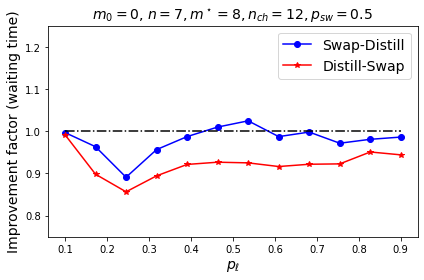

In [15]:
 #imp distill vs pl 
import matplotlib.pyplot as plt
import numpy as np
wt = np.load('data/wt_FN_pl_7912pt5m1_new.npy')
age = np.load("data/fid_FN_pl_7912pt5m1_new.npy")-1

wt_swdl = np.load('data/wt_FN_swdl_pl_7912pt5m1_new.npy')
age_swdl = np.load('data/fid_FN_swdl_pl_7912pt5m1_new.npy')-1

wt_dlsw = np.load('data/wt_FN_dlsw_pl_7912pt5m1_new.npy')
age_dlsw = np.load('data/fid_FN_dlsw_pl_7912pt5m1_new.npy')-1

imp_swdl = np.divide(wt,wt_swdl)
# imp_swdl_std = np.sqrt(((wt_std+wt_std_swdl)/(wt-wt_swdl))**2 + (wt_std_swdl/wt_swdl)**2)*imp_swdl
imp_dlsw = np.divide(wt,wt_dlsw)
# imp_dlsw_std = np.sqrt(((wt_std+wt_std_dlsw)/(wt-wt_dlsw))**2 + (wt_std_dlsw/wt_dlsw)**2)*imp_dlsw



plt.plot(np.linspace(0.1, 0.9, 12),imp_swdl,color='b', marker='o')
plt.plot(np.linspace(0.1, 0.9, 12),imp_dlsw,color='r', marker='*')
plt.plot(np.linspace(0.1, 0.9, 12),[1]*12,color='black', linestyle='dashdot')
plt.title(r"$m_0 = 0$, $n = 7, m^\star = 8, n_{ch} = 12, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylim([0.75,1.25])
plt.ylabel("Improvement factor (waiting time)", fontsize = 14)
plt.legend(["Swap-Distill","Distill-Swap"],fontsize = 14)
plt.tight_layout()
plt.savefig("imp_pl_distillation_m0.pdf", bbox_inches='tight')

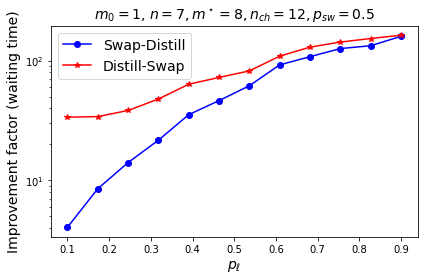

In [22]:
#imp distill vs pl 
import matplotlib.pyplot as plt
import numpy as np

wt = np.load('data/wt_FN_pl_7912pt5m2_new.npy')
age = np.load('data/fid_FN_pl_7912pt5m2_new.npy')-1

wt_swdl = np.load('data/wt_FN_swdl_pl_7912pt5m2_new.npy')
age_swdl = np.load('data/fid_FN_dlsw_pl_7912pt5m2_new.npy')-1

wt_dlsw = np.load('data/wt_FN_dlsw_pl_7912pt5m2_new.npy')
age_dlsw = np.load('data/fid_FN_dlsw_pl_7912pt5m2_new.npy')-1

plt.plot(np.linspace(0.1, 0.9, 12), np.divide(wt,wt_swdl),color='b', marker='o')
plt.plot(np.linspace(0.1, 0.9, 12),np.divide(wt,wt_dlsw),color='r', marker='*')
plt.yscale('log')
plt.title(r"$ m_0 = 1$, $n = 7, m^\star = 8, n_{ch} = 12, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("Improvement factor (waiting time)", fontsize = 14)
plt.legend(["Swap-Distill","Distill-Swap"],fontsize = 14)
plt.tight_layout()
plt.savefig("imp_pl_distillation_m1.pdf", bbox_inches='tight')

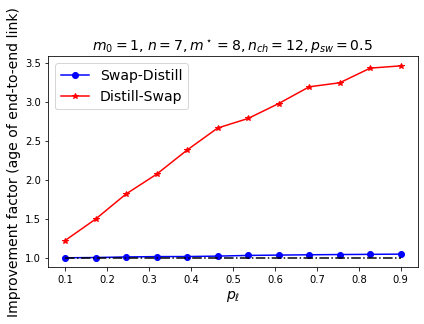

In [27]:
#imp distill vs pl 
import matplotlib.pyplot as plt
import numpy as np

wt = np.load('data/wt_FN_pl_7912pt5m2_new.npy')
age = np.load('data/fid_FN_pl_7912pt5m2_new.npy')-1

wt_swdl = np.load('data/wt_FN_swdl_pl_7912pt5m2_new.npy')
age_swdl = np.load('data/fid_FN_swdl_pl_7912pt5m2_new.npy')-1

wt_dlsw = np.load('data/wt_FN_dlsw_pl_7912pt5m2_new.npy')
age_dlsw = np.load('data/fid_FN_dlsw_pl_7912pt5m2_new.npy')-1

plt.plot(np.linspace(0.1, 0.9, 12), np.divide(age,age_swdl),color='b', marker='o')
plt.plot(np.linspace(0.1, 0.9, 12),np.divide(age,age_dlsw),color='r', marker='*')

# plt.yscale('log')
plt.title(r"$ m_0 = 1$, $n = 7, m^\star = 8, n_{ch} = 12, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("Improvement factor (age of end-to-end link)", fontsize = 14)
plt.legend(["Swap-Distill","Distill-Swap"],fontsize = 14)
plt.tight_layout()
plt.savefig("imp_pl_distillation_m1_age.pdf", bbox_inches='tight')

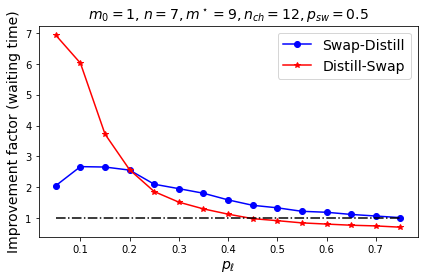

In [21]:
 #imp distill vs pl 
import matplotlib.pyplot as plt
import numpy as np
wt = np.load('data/wt_FN_pl_71012pt5m2_new.npy')
age = np.load("data/fid_FN_pl_71012pt5m2_new.npy")-1

wt_swdl = np.load('data/wt_FN_swdl_pl_71012pt5m2_new.npy')
age_swdl = np.load('data/fid_FN_dlsw_pl_71012pt5m2_new.npy')-1


wt_dlsw = np.load('data/wt_FN_dlsw_pl_71012pt5m2_new.npy')
age_dlsw = np.load('data/fid_FN_dlsw_pl_71012pt5m2_new.npy')-1

imp_swdl = np.divide(wt, wt_swdl)
imp_dlsw = np.divide(wt, wt_dlsw)

plt.plot(np.linspace(0.05,0.75,15),imp_swdl,color='b', marker='o')
plt.plot(np.linspace(0.05,0.75,15),imp_dlsw,color='r', marker='*')
plt.plot(np.linspace(0.05,0.75,15),[1]*15,color='black', linestyle='dashdot')

plt.title(r"$ m_0 = 1$, $n = 7, m^\star = 9, n_{ch} = 12, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("Improvement factor (waiting time)", fontsize = 14)
plt.legend(["Swap-Distill","Distill-Swap"],fontsize = 14)
plt.tight_layout()
plt.savefig("imp_pl_distillation_m1_swdl_vs_dlsw.pdf", bbox_inches='tight')

In [78]:
print("FN+SN")

n = 7
m_star = 6
n_ch = 5
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []
m=1
K=4
q=0
for p_l in np.linspace(0.1,0.5,10):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'optimal',m,K,a,q,r) for i in range(200))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('data/fid_SN_opt_pl_965_pt5.npy', fid_all)


n = 7
m_star = 6
n_ch = 5
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []
m=1
K=4
q=0
for p_l in np.linspace(0.1,0.5,10):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'age',m,K,a,q,r) for i in range(200))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('data/fid_SN_965_pt5.npy', fid_all)

FN+SN
0.1
0
1
2
3
4
5
6
7
8
9
412.2745 24.539179840614075 3.2925000000000004 0.03523137805990557
0.14444444444444446
0
1
2
3
4
5
6
7
8
9
145.4835 6.7727660708162665 3.1455 0.07938671173439552
0.18888888888888888
0
1
2
3
4
5
6
7
8
9
73.2455 4.105757207872866 2.995 0.06426507605223857
0.23333333333333334
0
1
2
3
4
5
6
7
8
9
47.926 3.0638315880609364 2.8875 0.0550567888638632
0.2777777777777778
0
1
2
3
4
5
6
7
8
9
34.552 1.2940057959684728 2.689 0.09855962662266946
0.32222222222222224
0
1
2
3
4
5
6
7
8
9
25.6955 1.9725015209119614 2.5715000000000003 0.10312734845810792
0.3666666666666667
0
1
2
3
4
5
6
7
8
9
21.4255 1.1482191646197168 2.4585 0.06332653472281585
0.4111111111111111
0
1
2
3
4
5
6
7
8
9
18.098999999999997 0.6091871633578636 2.4189999999999996 0.045814844755821184
0.4555555555555556
0
1
2
3
4
5
6
7
8
9
15.535500000000003 1.083006117249575 2.303 0.08503528679318957
0.5
0
1
2
3
4
5
6
7
8
9
13.582500000000001 0.5229686893113199 2.1975000000000002 0.08195273027788637
0.1
0
1
2
3
4


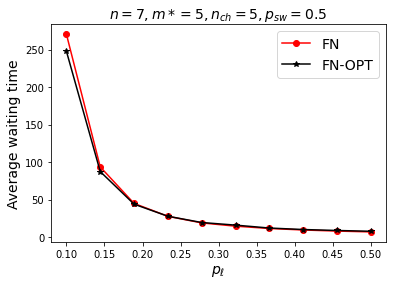

In [73]:
import matplotlib.pyplot as plt
wt_opt = np.load('data/wt_FN_opt_pl_965_pt5.npy')
wt_FN = np.load('data/wt_FN_965_pt5.npy')
plt.plot(np.linspace(0.1,0.5,10), wt_FN, marker='o', color='r')
plt.plot(np.linspace(0.1,0.5,10), wt_opt, marker='*', color='black')
plt.xlabel(r'$p_\ell$', fontsize=14)
plt.ylabel('Average waiting time', fontsize=14)
plt.title(r'$n = 7, m*=5, n_{ch} = 5, p_{sw}=0.5$', fontsize=14)
plt.legend(['FN', 'FN-OPT'], fontsize=14)
plt.savefig('optvsSN_fid.pdf')

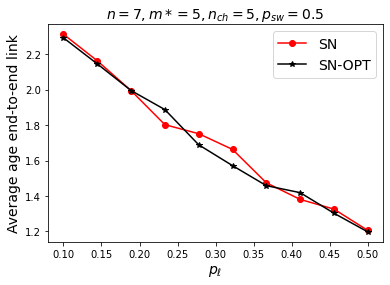

In [79]:
import matplotlib.pyplot as plt
fid_opt = np.load('data/fid_SN_opt_pl_965_pt5.npy')-1
fid_SN = np.load('data/fid_SN_965_pt5.npy')-1
plt.plot(np.linspace(0.1,0.5,10), fid_SN, marker='o', color='r')
plt.plot(np.linspace(0.1,0.5,10), fid_opt, marker='*', color='black')
plt.xlabel(r'$p_\ell$', fontsize=14)
plt.ylabel('Average age end-to-end link', fontsize=14)
plt.title(r'$n = 7, m*=5, n_{ch} = 5, p_{sw}=0.5$', fontsize=14)
plt.legend(['SN', 'SN-OPT'], fontsize=14)
plt.savefig('optvsSN_age.pdf')

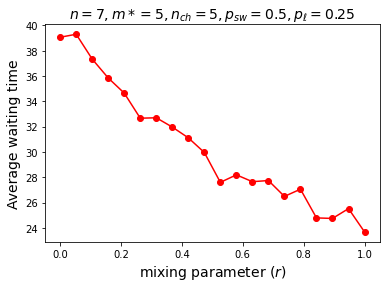

In [65]:
import matplotlib.pyplot as plt
wt = np.load('data/wt_FN_SN_rnd_plpt25_965_pt5.npy')
plt.plot(np.linspace(0,1,20), wt, marker='o', color='r')
plt.xlabel(r'mixing parameter ($r$)', fontsize=14)
plt.ylabel('Average waiting time', fontsize=14)
plt.title(r'$n = 7, m*=5, n_{ch} = 5, p_{sw}=0.5, p_\ell = 0.25$', fontsize=14)
plt.savefig('rnd_mixed_policy_wt.pdf')

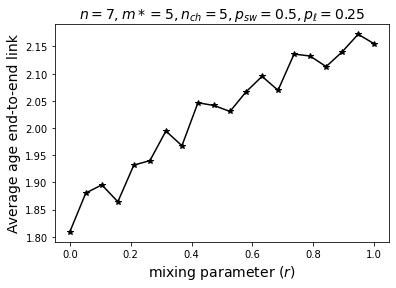

In [66]:
fid = np.load('data/fid_FN_SN_rnd_plpt25_965_pt5.npy')-1
plt.plot(np.linspace(0,1,20), fid, marker='*', color='black')
plt.xlabel(r'mixing parameter ($r$)', fontsize=14)
plt.ylabel('Average age end-to-end link', fontsize=14)
plt.title(r'$n = 7, m*=5, n_{ch} = 5, p_{sw}=0.5, p_\ell = 0.25$', fontsize=14)
plt.savefig('rnd_mixed_policy_fid.pdf')

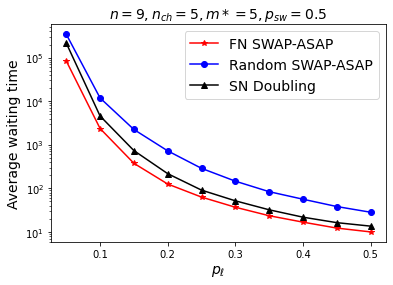

In [57]:
wt_FN = [83971.337, 2359.143, 374.979, 125.29, 62.836, 36.766, 23.479, 16.715, 12.215, 9.973]
fid_FN = np.array([4.739, 4.662, 4.528, 4.447, 4.327, 4.232, 4.153, 4.013, 3.903, 3.775])-1

wt_SN = [122855.666, 3558.446, 660.678, 233.07, 124.904, 67.476, 44.609, 29.828, 23.284, 17.184]
fid_SN = np.array([4.686, 4.525, 4.409, 4.199, 4.084, 3.925, 3.866, 3.715, 3.561, 3.461])-1

wt_RND = [344332.769, 11843.921, 2240.338, 723.414, 287.118, 145.810, 83.658, 56.167, 38.138, 28.222]
fid_RND = np.array([4.771, 4.709, 4.654, 4.614, 4.561, 4.521, 4.429, 4.404, 4.369, 4.276])-1

wt_DBL = np.load('data/wt_double_pl_965_pt5.npy')
fid_DBL = np.load('data/fid_double_pl_965_pt5.npy')-1

plt.title(r"$n=9, n_{ch} = 5, m* = 5, p_{sw} = 0.5$", fontsize=14)
plt.plot(np.linspace(0.05, 0.5, 10),wt_FN,color='red',marker='*')
# plt.plot(np.linspace(0.05, 0.5, 10),wt_SN,color='green',marker='*')
plt.plot(np.linspace(0.05, 0.5, 10),wt_RND,color='blue',marker='o')
plt.plot(np.linspace(0.05, 0.5, 10),wt_DBL,color='black',marker='^')
plt.ylabel("Average waiting time", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(["FN SWAP-ASAP", "Random SWAP-ASAP", "SN Doubling"], fontsize=14)
plt.yscale('log')

plt.savefig("doubling_vs_SA.pdf")


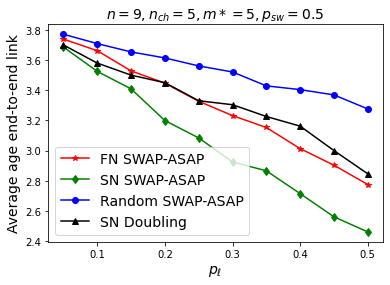

In [65]:
wt_FN = [83971.337, 2359.143, 374.979, 125.29, 62.836, 36.766, 23.479, 16.715, 12.215, 9.973]
fid_FN = np.array([4.739, 4.662, 4.528, 4.447, 4.327, 4.232, 4.153, 4.013, 3.903, 3.775])-1

wt_SN = [122855.666, 3558.446, 660.678, 233.07, 124.904, 67.476, 44.609, 29.828, 23.284, 17.184]
fid_SN = np.array([4.686, 4.525, 4.409, 4.199, 4.084, 3.925, 3.866, 3.715, 3.561, 3.461])-1

wt_RND = [344332.769, 11843.921, 2240.338, 723.414, 287.118, 145.810, 83.658, 56.167, 38.138, 28.222]
fid_RND = np.array([4.771, 4.709, 4.654, 4.614, 4.561, 4.521, 4.429, 4.404, 4.369, 4.276])-1

wt_DBL = np.load('data/wt_double_pl_965_pt5.npy')
fid_DBL = np.load('data/fid_double_pl_965_pt5.npy')-1

plt.title(r"$n=9, n_{ch} = 5, m* = 5, p_{sw} = 0.5$", fontsize=14)
plt.plot(np.linspace(0.05, 0.5, 10),fid_FN,color='red',marker='*')
plt.plot(np.linspace(0.05, 0.5, 10),fid_SN,color='green',marker='d')
plt.plot(np.linspace(0.05, 0.5, 10),fid_RND,color='blue',marker='o')
plt.plot(np.linspace(0.05, 0.5, 10),fid_DBL,color='black',marker='^')
plt.ylabel("Average age end-to-end link", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(["FN SWAP-ASAP", "SN SWAP-ASAP", "Random SWAP-ASAP", "SN Doubling"], fontsize=14)
# plt.yscale('log')

plt.savefig("doubling_vs_SA_fid.pdf")

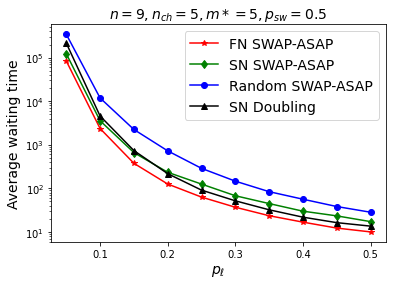

In [66]:
plt.title(r"$n=9, n_{ch} = 5, m* = 5, p_{sw} = 0.5$", fontsize=14)
plt.plot(np.linspace(0.05, 0.5, 10),wt_FN,color='red',marker='*')
plt.plot(np.linspace(0.05, 0.5, 10),wt_SN,color='green',marker='d')
plt.plot(np.linspace(0.05, 0.5, 10),wt_RND,color='blue',marker='o')
plt.plot(np.linspace(0.05, 0.5, 10),wt_DBL,color='black',marker='^')
plt.ylabel("Average waiting time", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(["FN SWAP-ASAP", "SN SWAP-ASAP", "Random SWAP-ASAP", "SN Doubling"], fontsize=14)
plt.yscale('log')

plt.savefig("doubling_vs_SA.pdf")

In [ ]:
n = 7
m_star = 8
n_ch = 12
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []
m=2
K=4
for p_l in np.linspace(0.1,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist',m,K,dl=False,sw_dl=True) for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_FN_pl_7812pt5.npy', wt_all)
np.save('fid_FN_pl_7812pt5.npy', fid_all)
np.save('wt_std_FN_pl_7812pt5.npy', wt_std)
np.save('fid_std_FN_pl_7812pt5.npy', fid_std)


n = 7
m_star = 8
n_ch = 12
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []
m = 2
K = 4

for p_l in np.linspace(0.1,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist',m,K,dl=True,sw_dl=True) for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))

    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_swdl_pl_7812pt5.npy', wt_all)
np.save('fid_swdl_pl_7812pt5.npy', fid_all)
np.save('wt_std_swdl_pl_7812pt5.npy', wt_std)
np.save('fid_std_swdl_pl_7812pt5.npy', fid_std)

n = 7
m_star = 8
n_ch = 12
p_sw = 0.5
m = 2
wt_all = []
fid_all = []
wt_std = []
fid_std = []
K = 4
for p_l in np.linspace(0.1,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist',m,K,dl=True, sw_dl=False) for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_dlsw_pl_7812pt5.npy', wt_all)
np.save('fid_dlsw_pl_7812pt5.npy', fid_all)
np.save('wt_std_dlsw_pl_7812pt5.npy', wt_std)
np.save('fid_std_dlsw_pl_7812pt5.npy', fid_std)

0.1
0


In [8]:
#parallel 
n = 9
m_star = 6
n_ch_ch = 5
p_sw = 0.5
wt_all=[]
fid_all=[]
wt_std=[]
fid_std=[]
m = 1
for p_l in np.linspace(0.1,0.5,10):
    print(p_l)
    wt_wt=[]
    fid_fid=[]

    for k in range(1):
        print(k)
        wt_list = Parallel(n_jobs=200,verbose=50)(delayed(wt_fid_parallel)(n,1,m_star,n_ch_ch,p_l,p_sw,m) for i in range(200))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))

    print(n, np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_PRL_pl_965pt5.npy', wt_all)
np.save('fid_PRL_pl_965pt5.npy', fid_all)
np.save('wt_std_PRL_pl_965pt5.npy', wt_std)
np.save('fid_std_PRL_pl_965pt5.npy', fid_std)

0.1
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    1.7s
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    9.9s remaining:  5.3min
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:   11.9s remaining:  3.1min
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:   18.9s remaining:  3.2min
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:   26.2s remaining:  3.2min
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:   37.0s remaining:  3.5min
[Parallel(n_jobs=100)]: Done  18 out of 100 | elapsed:   46.0s remaining:  3.5min
[Parallel(n_jobs=100)]: Done  21 out of 100 | elapsed:   59.7s remaining:  3.7min
[Parallel(n_jobs=100)]: Done  24 out of 100 | elapsed:  1.1min remaining:  3.6min
[Parallel(n_jobs=100)]: Done  27 out of 100 | elapsed:  1.2min remaining:  3.3min
[Parallel(n_jobs=100)]: Done  30 out of 100 | elapsed:  1.3min remaining:  3.1min
[Parallel(n_jobs=100)]: Done  33

[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:  8.7min remaining:   58.3s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:  9.2min remaining:   41.7s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed: 12.7min remaining:   31.7s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed: 26.4min finished
3
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    6.4s
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:   14.5s remaining:  7.8min
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:   15.8s remaining:  4.1min
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:   23.6s remaining:  4.0min
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:   28.9s remaining:  3.5min
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:   36.0s remaining:  3.4min
[Parallel(n_jobs=100)]: Done  18 out of 100 | elapsed:   40.8s remaining:  3.1min
[Parallel(n_jobs=100)]: Done  21 out of 100 | 

[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:  3.6min remaining:  1.2min
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:  3.9min remaining:  1.1min
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:  4.2min remaining:   59.3s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:  4.7min remaining:   53.3s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:  5.2min remaining:   46.8s
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:  5.8min remaining:   38.5s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:  6.4min remaining:   28.9s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:  8.0min remaining:   20.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed: 11.8min finished
6
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    9.7s remaining:  5.2min
[Parallel(n_jobs=100)]: Done   6 out of 100 | 

[Parallel(n_jobs=100)]: Done  66 out of 100 | elapsed:  5.3min remaining:  2.7min
[Parallel(n_jobs=100)]: Done  69 out of 100 | elapsed:  5.6min remaining:  2.5min
[Parallel(n_jobs=100)]: Done  72 out of 100 | elapsed:  5.9min remaining:  2.3min
[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:  6.3min remaining:  2.1min
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:  6.5min remaining:  1.8min
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:  7.0min remaining:  1.7min
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:  7.2min remaining:  1.4min
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:  7.5min remaining:  1.1min
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:  7.8min remaining:   52.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:  9.2min remaining:   41.6s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed: 10.2min remaining:   25.5s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed: 17.8min finished
9
[Parallel(n_jobs=100)]: 

[Parallel(n_jobs=100)]: Done  54 out of 100 | elapsed:   49.6s remaining:   42.2s
[Parallel(n_jobs=100)]: Done  57 out of 100 | elapsed:   52.3s remaining:   39.5s
[Parallel(n_jobs=100)]: Done  60 out of 100 | elapsed:   57.1s remaining:   38.0s
[Parallel(n_jobs=100)]: Done  63 out of 100 | elapsed:  1.0min remaining:   36.5s
[Parallel(n_jobs=100)]: Done  66 out of 100 | elapsed:  1.2min remaining:   35.9s
[Parallel(n_jobs=100)]: Done  69 out of 100 | elapsed:  1.2min remaining:   32.3s
[Parallel(n_jobs=100)]: Done  72 out of 100 | elapsed:  1.3min remaining:   30.1s
[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:  1.4min remaining:   27.3s
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:  1.5min remaining:   24.9s
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:  1.6min remaining:   22.2s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:  1.8min remaining:   20.0s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:  1.9min remaining:   16.8s
[Parallel(n_jobs

...

[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    3.2s finished
8
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=100)]: Batch computation too fast (0.1114s.) Setting batch_size=2.
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    0.3s remaining:    8.2s
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:    0.3s remaining:    5.2s
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:    0.4s remaining:    4.3s
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:    0.5s remaining:    3.6s
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:    0.5s remaining:    3.1s
[Parallel(n_jobs=100)]: Done  18 out of 100 | elapsed:    0.6s remaining:    2.5s
[Parallel(n_jobs=100)]: Done  21 out of 100 | elapsed:    0.6s remaining:    2.1s
[Parallel(n_jobs=100)]: Done  24 out of 100 | elapsed:    0.6s remaining:    1.8s
[Parallel(n_jobs=100)]: Done  27 out of 100 

[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.2s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    2.0s finished
1
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    0.2s remaining:    8.1s
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:    0.3s remaining:    4.6s
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:    0.3s remaining:    3.2s
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:    0.3s remaining:    2.4s
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:    0.4s remaining:    2.2s
[Parallel(n_jobs=100)]: Done  18 out of 100 | elapsed:    0.4s remaining:    2.0s
[Parallel(n_jobs=100)]: Done  21 out of 100 | 

[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:    1.0s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:    1.1s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:    1.1s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:    1.2s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.4s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    1.4s remaining:    0.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    1.5s finished
4
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=100)]: Batch computation too fast (0.1270s.) Setting batch_size=2.
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    0.1s remaining:    4.7s
[Parallel(n_jobs=100)]: Done   6 out of 100 

[Parallel(n_jobs=100)]: Done  66 out of 100 | elapsed:    0.9s remaining:    0.5s
[Parallel(n_jobs=100)]: Done  69 out of 100 | elapsed:    0.9s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  72 out of 100 | elapsed:    1.0s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:    1.0s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:    1.0s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:    1.1s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:    1.1s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:    1.2s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    1.6s remaining:    0.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    1.9s finished
7
[Parallel(n_jobs=100)]: 

[Parallel(n_jobs=100)]: Done  60 out of 100 | elapsed:    0.7s remaining:    0.5s
[Parallel(n_jobs=100)]: Done  63 out of 100 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  66 out of 100 | elapsed:    0.8s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  69 out of 100 | elapsed:    0.8s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  72 out of 100 | elapsed:    0.8s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:    0.8s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:    0.9s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:    0.9s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:    1.0s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:    1.0s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.1s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.1s remaining:    0.1s
[Parallel(n_jobs

In [30]:
n = 7
m_star = 5
n_ch = 5
p_sw = 0.5
wt_all = []
fid_all = []
wt_std = []
fid_std = []

for p_l in np.linspace(0.05,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100,verbose=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist') for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
    fid_fid = np.array(fid_fid)-1
    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_FN_pl_755pt5.npy', wt_all)
np.save('fid_FN_pl_755pt5.npy', fid_all)
np.save('wt_std_FN_pl_755pt5.npy', wt_std)
np.save('fid_std_FN_pl_755pt5.npy', fid_std)

wt_all = []
fid_all = []
wt_std = []
fid_std = []

for p_l in np.linspace(0.05,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'age') for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
    fid_fid = np.array(fid_fid)-1
    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_SN_pl_755pt5.npy', wt_all)
np.save('fid_SN_pl_755pt5.npy', fid_all)
np.save('wt_std_SN_pl_755pt5.npy', wt_std)
np.save('fid_std_SN_pl_755pt5.npy', fid_std)

wt_all = []
fid_all = []
wt_std = []
fid_std = []

for p_l in np.linspace(0.05,0.5,11):
    wt_wt = []
    fid_fid = []
    print(p_l)
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'random') for i in range(500))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
    fid_fid = np.array(fid_fid)-1
    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

np.save('wt_RND_pl_755pt5.npy', wt_all)
np.save('fid_RND_pl_755pt5.npy', fid_all)
np.save('wt_std_RND_pl_755pt5.npy', wt_std)
np.save('fid_std_RND_pl_755pt5.npy', fid_std)

0.1
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    1.5s
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    1.5s remaining:   49.9s
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:    1.8s remaining:   27.6s
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:    2.2s remaining:   22.5s
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:    2.7s remaining:   19.6s
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:    3.1s remaining:   17.5s
[Parallel(n_jobs=100)]: Done  18 out of 100 | elapsed:    3.4s remaining:   15.7s
[Parallel(n_jobs=100)]: Done  21 out of 100 | elapsed:    3.6s remaining:   13.4s
[Parallel(n_jobs=100)]: Done  24 out of 100 | elapsed:    3.9s remaining:   12.3s
[Parallel(n_jobs=100)]: Done  27 out of 100 | elapsed:    4.7s remaining:   12.8s
[Parallel(n_jobs=100)]: Done  30 out of 100 | elapsed:    5.2s remaining:   12.1s
[Parallel(n_jobs=100)]: Done  33

[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    3.4s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    3.6s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    3.8s remaining:    0.2s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    5.2s finished
78.3 0.0 2.59 0.0
0.22
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=100)]: Batch computation too fast (0.1943s.) Setting batch_size=2.
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    0.3s remaining:    9.7s
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:    0.4s remaining:    5.9s
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:    0.4s remaining:    4.4s
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:    0.5s remaining:    4.0s
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:    0.6s remaining:    3.7s
[Parallel(n_jobs=100)

[Parallel(n_jobs=100)]: Done  75 out of 100 | elapsed:    1.2s remaining:    0.4s
[Parallel(n_jobs=100)]: Done  78 out of 100 | elapsed:    1.2s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  81 out of 100 | elapsed:    1.3s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  84 out of 100 | elapsed:    1.3s remaining:    0.3s
[Parallel(n_jobs=100)]: Done  87 out of 100 | elapsed:    1.4s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.5s remaining:    0.2s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.6s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    1.7s remaining:    0.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    2.1s finished
22.5 0.0 2.47 0.0
0.33999999999999997
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=100)]: Batch computation too fast (0.1700s.) Setting batch_size=2.
[Paral

[Parallel(n_jobs=100)]: Done  90 out of 100 | elapsed:    1.1s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  93 out of 100 | elapsed:    1.1s remaining:    0.1s
[Parallel(n_jobs=100)]: Done  96 out of 100 | elapsed:    1.2s remaining:    0.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    1.5s finished
13.17 0.0 2.37 0.0
0.45999999999999996
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=100)]: Batch computation too fast (0.1006s.) Setting batch_size=2.
[Parallel(n_jobs=100)]: Done   3 out of 100 | elapsed:    0.2s remaining:    7.6s
[Parallel(n_jobs=100)]: Done   6 out of 100 | elapsed:    0.3s remaining:    4.3s
[Parallel(n_jobs=100)]: Done   9 out of 100 | elapsed:    0.3s remaining:    3.5s
[Parallel(n_jobs=100)]: Done  12 out of 100 | elapsed:    0.4s remaining:    2.7s
[Parallel(n_jobs=100)]: Done  15 out of 100 | elapsed:    0.4s remaining:    2.3s
[Para

In [31]:
#wt_all_no_distill_nocutoff = does not work
wt_all_dlsw = [1796.34, 324.33, 136.57, 84.56, 46.55, 28.43, 19.8, 20.88, 11.55, 12.27, 8.38]
wt_all_swdl = [4523.92,
 1151.29,
 494.07,
 219.74,
 97.0,
 59.5,
 35.72,
 22.63,
 16.49,
 10.09,
 9.71]
wt_all_swdl_cutoff = [504.68, 181.07, 62.28, 39.28, 32.04, 18.21, 17.33, 14.68, 11.18, 8.03, 9.08]
wt_all_dlsw_cutoff = [553.71, 208.83, 78.3, 49.92, 32.81, 22.5, 17.33, 14.04, 13.17, 10.95, 9.85]

[553.71, 208.83, 78.3, 49.92, 32.81, 22.5, 17.33, 14.04, 13.17, 10.95, 9.85]

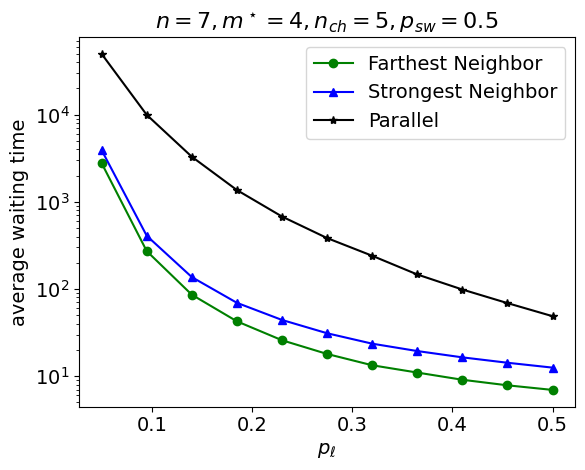

In [16]:
#sn fn parallel 
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
import numpy as np
wt_PRL = np.load("data/wt_PRL_pl_755pt5.npy")
wt_std_PRL = np.load("data/wt_std_PRL_pl_755pt5.npy")
age_PRL = np.load("data/fid_PRL_pl_755pt5.npy")
age_std_PRL = np.load("data/fid_std_PRL_pl_755pt5.npy") 

wt_SN = np.load("data/wt_SN_pl_755pt5.npy")
wt_std_SN = np.load("data/wt_std_SN_pl_755pt5.npy")
age_SN = np.load("data/fid_SN_pl_755pt5.npy")
age_std_SN = np.load("data/fid_std_SN_pl_755pt5.npy") 

wt_FN = np.load("data/wt_FN_pl_755pt5.npy")
wt_std_FN = np.load("data/wt_std_FN_pl_755pt5.npy")
age_FN = np.load("data/fid_FN_pl_755pt5.npy")
age_std_FN = np.load("data/fid_std_FN_pl_755pt5.npy") 


plt.plot(np.linspace(0.05, 0.5, 11),wt_FN,color='g', marker='o')
plt.plot(np.linspace(0.05, 0.5, 11),wt_SN,color='b', marker='^')
plt.plot(np.linspace(0.05, 0.5, 11),wt_PRL,color='black',marker='*')
plt.title(r"$n = 7, m^\star = 4, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 16)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average waiting time", fontsize = 14)
plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(["Farthest Neighbor","Strongest Neighbor","Parallel"],fontsize = 14)
plt.savefig("wt_multiplex_vs_prl.pdf")
plt.show()

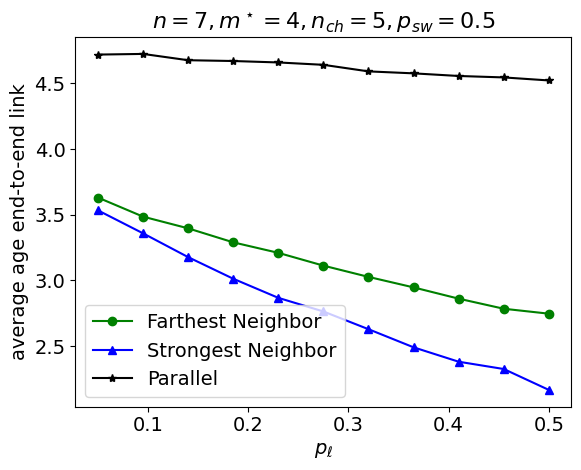

In [15]:
#sn fn parallel 
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
import numpy as np
wt_PRL = np.load("data/wt_PRL_pl_755pt5.npy")
wt_std_PRL = np.load("data/wt_std_PRL_pl_755pt5.npy")
age_PRL = np.load("data/fid_PRL_pl_755pt5.npy")
age_std_PRL = np.load("data/fid_std_PRL_pl_755pt5.npy") 

wt_SN = np.load("data/wt_SN_pl_755pt5.npy")
wt_std_SN = np.load("data/wt_std_SN_pl_755pt5.npy")
age_SN = np.load("data/fid_SN_pl_755pt5.npy")
age_std_SN = np.load("data/fid_std_SN_pl_755pt5.npy") 

wt_FN = np.load("data/wt_FN_pl_755pt5.npy")
wt_std_FN = np.load("data/wt_std_FN_pl_755pt5.npy")
age_FN = np.load("data/fid_FN_pl_755pt5.npy")
age_std_FN = np.load("data/fid_std_FN_pl_755pt5.npy") 


plt.plot(np.linspace(0.05, 0.5, 11),age_FN,color='g', marker='o')
plt.plot(np.linspace(0.05, 0.5, 11),age_SN,color='b', marker='^')
plt.plot(np.linspace(0.05, 0.5, 11),age_PRL,color='black',marker='*')
plt.title(r"$n = 7, m^\star = 4, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 16)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average age end-to-end link", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(["Farthest Neighbor","Strongest Neighbor","Parallel"],fontsize = 14)
plt.savefig("age_multiplex_vs_prl.pdf")
plt.show()

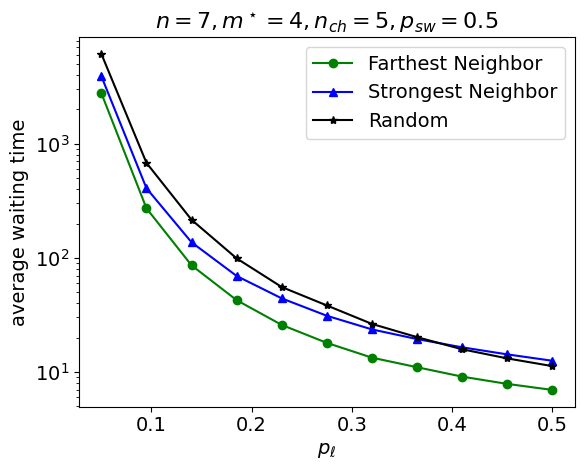

In [5]:
#sn fn random 
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
import numpy as np
wt_RND = np.load("data/wt_RND_pl_755pt5.npy")
wt_std_RND = np.load("data/wt_std_RND_pl_755pt5.npy")
age_RND = np.load("data/fid_RND_pl_755pt5.npy")
age_std_RND = np.load("data/fid_std_RND_pl_755pt5.npy") 

wt_SN = np.load("data/wt_SN_pl_755pt5.npy")
wt_std_SN = np.load("data/wt_std_SN_pl_755pt5.npy")
age_SN = np.load("data/fid_SN_pl_755pt5.npy")
age_std_SN = np.load("data/fid_std_SN_pl_755pt5.npy") 

wt_FN = np.load("data/wt_FN_pl_755pt5.npy")
wt_std_FN = np.load("data/wt_std_FN_pl_755pt5.npy")
age_FN = np.load("data/fid_FN_pl_755pt5.npy")
age_std_FN = np.load("data/fid_std_FN_pl_755pt5.npy") 


plt.plot(np.linspace(0.05, 0.5, 11),wt_FN,color='g', marker='o')
plt.plot(np.linspace(0.05, 0.5, 11),wt_SN,color='b', marker='^')
plt.plot(np.linspace(0.05, 0.5, 11),wt_RND,color='black',marker='*')
plt.title(r"$n = 7, m^\star = 4, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 16)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average waiting time", fontsize = 14)
plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(["Farthest Neighbor","Strongest Neighbor","Random"],fontsize = 14)
plt.savefig("wt_multiplex.pdf")

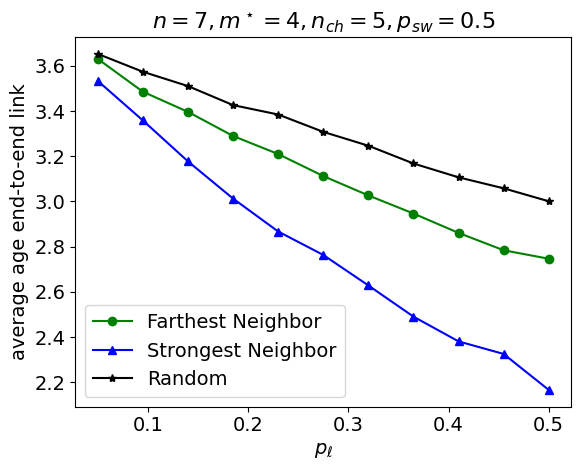

In [6]:
plt.plot(np.linspace(0.05, 0.5, 11),age_FN,color='g', marker='o')
plt.plot(np.linspace(0.05, 0.5, 11),age_SN,color='b', marker='^')
plt.plot(np.linspace(0.05, 0.5, 11),age_RND,color='black',marker='*')
plt.title(r"$n = 7, m^\star = 4, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 16)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average age end-to-end link", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(["Farthest Neighbor","Strongest Neighbor","Random"],fontsize = 14)
plt.savefig("age_multiplex.pdf")

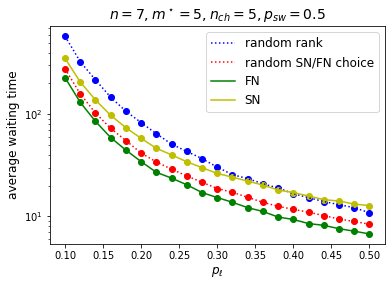

In [38]:
import matplotlib.pyplot as plt
import numpy as np
wt_rnd = np.load("wt_low2pl_n7c5m5_random.npy")
fid_rnd = np.load("fid_low2pl_n7c5m5_random.npy")

wt_rnd2 = np.load("wt_low2pl_n7c5m5_random2.npy")
fid_rnd2 = np.load("fid_low2pl_n7c5m5_random2.npy")

wt_FN = np.load("wt_low2pl_n7c5m5_FN.npy")
fid_FN = np.load("fid_low2pl_n7c5m5_FN.npy")

wt_SN = np.load("wt_low2pl_n7c5m5_SN.npy")
fid_SN = np.load("fid_low2pl_n7c5m5_SN.npy")
 
p_list = np.linspace(0.1,0.5,21)

plt.plot(p_list,wt_rnd,color='b', linestyle='dotted')
plt.scatter(p_list,wt_rnd,color='b')
plt.plot(p_list,wt_rnd2,color='r', linestyle='dotted')
plt.scatter(p_list,wt_rnd2,color='r')

plt.plot(p_list,wt_FN,color='g')
plt.scatter(p_list,wt_FN,color='g')
plt.plot(p_list,wt_SN,color='y')
plt.scatter(p_list,wt_SN,color='y')

plt.title(r"$n = 7, m^\star = 5, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 12)
plt.ylabel("average waiting time", fontsize = 12)
plt.legend(["random rank","random SN/FN choice", "FN", "SN"],fontsize = 12)
plt.yscale('log')
plt.savefig("random_policies.pdf")

In [12]:
n = 7
m_star = 5
p_sw = 0.5
wt_all = np.zeros([10,10])
fid_all = np.zeros([10,10])
wt_std = np.zeros([10,10])
fid_std = np.zeros([10,10])
i=-1
for p_l in np.linspace(0.1,1,10):
    i+=1
    j=-1
    for n_ch in range(1,11):
        j+=1
        wt_wt = []
        fid_fid = []
        print(p_l)
        for k in range(10):
            print(k)
            wt_list = Parallel(n_jobs=100,verbose=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist') for i in range(500))
            wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
            fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
        fid_fid = np.array(fid_fid)-1
        print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
        wt_all[i,j] = np.mean(wt_wt)
        fid_all[i,j] = np.mean(fid_fid)
        wt_std[i,j] = np.std(wt_wt)
        fid_std[i,j] = np.std(fid_fid)

np.save('wt_FN_2d_pl.npy', wt_all)
np.save('fid_FN_2d_pl.npy', fid_all)
np.save('wt_std_FN_2d_pl.npy', wt_std)
np.save('fid_std_FN_2d_pl.npy', fid_std)

n = 7
m_star = 5
p_sw = 0.5
wt_all = np.zeros([10,10])
fid_all = np.zeros([10,10])
wt_std = np.zeros([10,10])
fid_std = np.zeros([10,10])
i=-1
for p_l in np.linspace(0.1,1,10):
    i+=1
    j=-1
    for n_ch in range(1,11):
        j+=1
        wt_wt = []
        fid_fid = []
        print(p_l)
        for k in range(10):
            print(k)
            wt_list = Parallel(n_jobs=100,verbose=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'age') for i in range(500))
            wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
            fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
        fid_fid = np.array(fid_fid)-1
        print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
        wt_all[i,j] = np.mean(wt_wt)
        fid_all[i,j] = np.mean(fid_fid)
        wt_std[i,j] = np.std(wt_wt)
        fid_std[i,j] = np.std(fid_fid)

np.save('wt_SN_2d_pl.npy', wt_all)
np.save('fid_SN_2d_pl.npy', fid_all)
np.save('wt_std_SN_2d_pl.npy', wt_std)
np.save('fid_std_SN_2d_pl.npy', fid_std)


n = 7
p_l = 0.25
p_sw = 0.5
wt_all = np.zeros([10,10])
fid_all = np.zeros([10,10])
wt_std = np.zeros([10,10])
fid_std = np.zeros([10,10])
i=-1
for m_star in range(1,11):
    i+=1
    j=-1
    for n_ch in range(1,11):
        j+=1
        wt_wt = []
        fid_fid = []
        print(p_l)
        for k in range(10):
            print(k)
            wt_list = Parallel(n_jobs=100,verbose=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist') for i in range(500))
            wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
            fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
        fid_fid = np.array(fid_fid)-1
        print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
        wt_all[i,j] = np.mean(wt_wt)
        fid_all[i,j] = np.mean(fid_fid)
        wt_std[i,j] = np.std(wt_wt)
        fid_std[i,j] = np.std(fid_fid)

np.save('wt_FN_2d_m.npy', wt_all)
np.save('fid_FN_2d_m.npy', fid_all)
np.save('wt_std_FN_2d_m.npy', wt_std)
np.save('fid_std_FN_2d_m.npy', fid_std)

n = 7
p_l = 0.25
p_sw = 0.5
wt_all = np.zeros([10,10])
fid_all = np.zeros([10,10])
wt_std = np.zeros([10,10])
fid_std = np.zeros([10,10])
i=-1
for m_star in range(1,11):
    i+=1
    j=-1
    for n_ch in range(1,11):
        j+=1
        wt_wt = []
        fid_fid = []
        print(p_l)
        for k in range(10):
            print(k)
            wt_list = Parallel(n_jobs=100,verbose=50)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'age') for i in range(500))
            wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
            fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))]))
        fid_fid = np.array(fid_fid)-1
        print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
        wt_all[i,j] = np.mean(wt_wt)
        fid_all[i,j] = np.mean(fid_fid)
        wt_std[i,j] = np.std(wt_wt)
        fid_std[i,j] = np.std(fid_fid)

np.save('wt_SN_2d_m.npy', wt_all)
np.save('fid_SN_2d_m.npy', fid_all)
np.save('wt_std_SN_2d_m.npy', wt_std)
np.save('fid_std_SN_2d_m.npy', fid_std)

0.1
0
[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:   14.9s
[Parallel(n_jobs=100)]: Done   2 tasks      | elapsed:   25.8s
[Parallel(n_jobs=100)]: Done   3 tasks      | elapsed:  1.2min
[Parallel(n_jobs=100)]: Done   4 tasks      | elapsed:  1.3min
[Parallel(n_jobs=100)]: Done   5 tasks      | elapsed:  1.5min
[Parallel(n_jobs=100)]: Done   6 tasks      | elapsed:  1.8min
[Parallel(n_jobs=100)]: Done   7 tasks      | elapsed:  2.0min
[Parallel(n_jobs=100)]: Done   8 tasks      | elapsed:  2.4min
[Parallel(n_jobs=100)]: Done   9 tasks      | elapsed:  3.0min
[Parallel(n_jobs=100)]: Done  10 tasks      | elapsed:  4.2min
[Parallel(n_jobs=100)]: Done  11 tasks      | elapsed:  4.2min
[Parallel(n_jobs=100)]: Done  12 tasks      | elapsed:  4.9min
[Parallel(n_jobs=100)]: Done  13 tasks      | elapsed:  5.5min
[Parallel(n_jobs=100)]: Done  14 tasks      | elapsed:  5.8min
[Parallel(n_jobs=100)]: Done  15 

[Parallel(n_jobs=100)]: Done 130 tasks      | elapsed: 60.1min
[Parallel(n_jobs=100)]: Done 131 tasks      | elapsed: 60.4min
[Parallel(n_jobs=100)]: Done 132 tasks      | elapsed: 60.9min
[Parallel(n_jobs=100)]: Done 133 tasks      | elapsed: 61.4min
[Parallel(n_jobs=100)]: Done 134 tasks      | elapsed: 62.3min
[Parallel(n_jobs=100)]: Done 135 tasks      | elapsed: 62.6min
[Parallel(n_jobs=100)]: Done 136 tasks      | elapsed: 62.6min
[Parallel(n_jobs=100)]: Done 137 tasks      | elapsed: 63.0min
[Parallel(n_jobs=100)]: Done 138 tasks      | elapsed: 63.1min
[Parallel(n_jobs=100)]: Done 139 tasks      | elapsed: 63.6min
[Parallel(n_jobs=100)]: Done 140 tasks      | elapsed: 63.9min
[Parallel(n_jobs=100)]: Done 141 tasks      | elapsed: 64.1min
[Parallel(n_jobs=100)]: Done 142 tasks      | elapsed: 64.2min
[Parallel(n_jobs=100)]: Done 143 tasks      | elapsed: 64.3min
[Parallel(n_jobs=100)]: Done 144 tasks      | elapsed: 64.6min
[Parallel(n_jobs=100)]: Done 145 tasks      | elapsed: 

[Parallel(n_jobs=100)]: Done 260 tasks      | elapsed: 128.0min
[Parallel(n_jobs=100)]: Done 261 tasks      | elapsed: 128.2min
[Parallel(n_jobs=100)]: Done 262 tasks      | elapsed: 128.3min
[Parallel(n_jobs=100)]: Done 263 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 264 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 265 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 266 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 267 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 268 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 269 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 270 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 271 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 272 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 273 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 274 tasks      | elapsed: 128.5min
[Parallel(n_jobs=100)]: Done 275 tasks  

KeyboardInterrupt: 

In [32]:
import numpy as np
import math
from numpy import linalg as LA
m = 6
m_star = 10
a00 = np.kron(np.array([0,1]), np.array([0,1]))
a01 = np.kron(np.array([0,1]), np.array([1,0]))
a10 = np.kron(np.array([1,0]), np.array([0,1]))
a11 = np.kron(np.array([1,0]), np.array([1,0]))

t1 = (1+3*math.exp(-m/m_star))*(np.outer(a00,a00) + np.outer(a10,a01) + np.outer(a01,a10) + np.outer(a11,a11))
t2 = (1-math.exp(-m/m_star))*(np.outer(a00,a00) - np.outer(a10,a01) - np.outer(a01,a10) + np.outer(a11,a11))
t3 = (1+math.exp(-m/m_star))*(np.outer(a01,a01) + np.outer(a11,a00) + np.outer(a00,a11) + np.outer(a10,a10))
t4 = (1-math.exp(-m/m_star))*(np.outer(a01,a01) - np.outer(a11,a00) - np.outer(a00,a11) + np.outer(a10,a10))

rho = 0.125*(t1+t2+t3+t4)

LA.eigvals(rho)

array([ 0.52440582,  0.25      ,  0.52440582, -0.02440582])

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 1]])